



#  Recap



Import the required libraries

In [ ]:
# First, let's import what we need
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_digits
from sklearn.model_selection import train_test_split

# Make plots look nice
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("Ready to explore data! 🚀")

Ready to explore data! 🚀


In [ ]:
# Some experiments
x=np.array([1,2,3])
print(type(x),x.shape,type(x.shape))

x=np.array([[1,2,3]])
print(x.shape)

x=np.array([[1],[2],[3]])
print(x.shape)

x=np.array([[1,2],[2,2],[3,2]])
print(x.shape)

<class 'numpy.ndarray'> (3,) <class 'tuple'>
(1, 3)
(3, 1)
(3, 2)


### Part 1: How Does Data Look Like?

---

#### Tabular Data (Spreadsheet-like)

In [ ]:
# Load the famous Iris dataset
iris = load_iris()

dict={"abc":1,"def":2}
print(dict.keys())
# What's in it? Iris is somewhat like a dictionary,but not exactly
print(iris.keys())
print("Type: ", type(iris))

#The most important part of the data set: data and target

print("Type of data and target", type(iris.data), type(iris.target))

print("\nShape of data:", iris.data.shape, iris.target.shape)

print("That's 150 flowers with 4 features each!\n", "="*20)

#------------------------------
#------ Some other information
print("Feature names:", iris.feature_names, type(iris.feature_names))
print("Target names:", iris.target_names, type(iris.target_names))
print("setosa is represented by 0, versicolo by 1, and virginica by 2")

dict_keys(['abc', 'def'])
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
Type:  <class 'sklearn.utils._bunch.Bunch'>
Type of data and target <class 'numpy.ndarray'> <class 'numpy.ndarray'>

Shape of data: (150, 4) (150,)
That's 150 flowers with 4 features each!
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'] <class 'list'>
Target names: ['setosa' 'versicolor' 'virginica'] <class 'numpy.ndarray'>
setosa is represented by 0, versicolo by 1, and virginica by 2


### Let's view the data and target

In [ ]:
print("The first 5 entries in data\n",iris.data[0:5])
print("The first 5 entries in target\n",iris.target[0:5])

The first 5 entries in data
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
The first 5 entries in target
 [0 0 0 0 0]


In [ ]:
# Let's look at the first 5 flowers in a better manner
import pandas as pd

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = [iris.target_names[i] for i in iris.target]
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


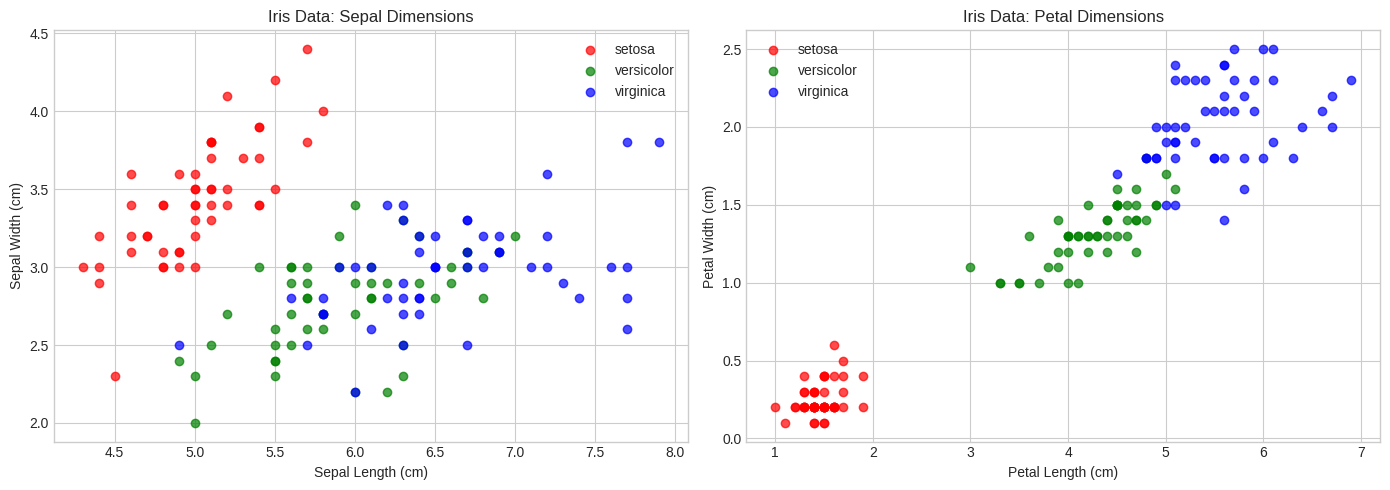

💡 Notice: Petal dimensions separate species much better than sepal!


In [ ]:
# @title
# Visualize: Can we see patterns?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Two features
colors = ['red', 'green', 'blue']
for i, species in enumerate(iris.target_names):
    mask = iris.target == i
    axes[0].scatter(iris.data[mask, 0], iris.data[mask, 1],
                    c=colors[i], label=species, alpha=0.7)
axes[0].set_xlabel('Sepal Length (cm)')
axes[0].set_ylabel('Sepal Width (cm)')
axes[0].legend()
axes[0].set_title('Iris Data: Sepal Dimensions')

# Plot 2: Different features
for i, species in enumerate(iris.target_names):
    mask = iris.target == i
    axes[1].scatter(iris.data[mask, 2], iris.data[mask, 3],
                    c=colors[i], label=species, alpha=0.7)
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].legend()
axes[1].set_title('Iris Data: Petal Dimensions')

plt.tight_layout()
plt.show()

print("💡 Notice: Petal dimensions separate species much better than sepal!")

### Image Data

In [ ]:
# Load handwritten digits (MNIST-like)
digits = load_digits()

print(digits.keys())

print(digits.data.shape)

print(digits.data[0].shape) # this is actually used in the model training


print("Shape of one image:", digits.images[0].shape) # this is for viewing purpose.
print("That's 8x8 = 64 pixels per image")
print("Total images:", len(digits.images))
print(digits.data[0])

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
(1797, 64)
(64,)
Shape of one image: (8, 8)
That's 8x8 = 64 pixels per image
Total images: 1797
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


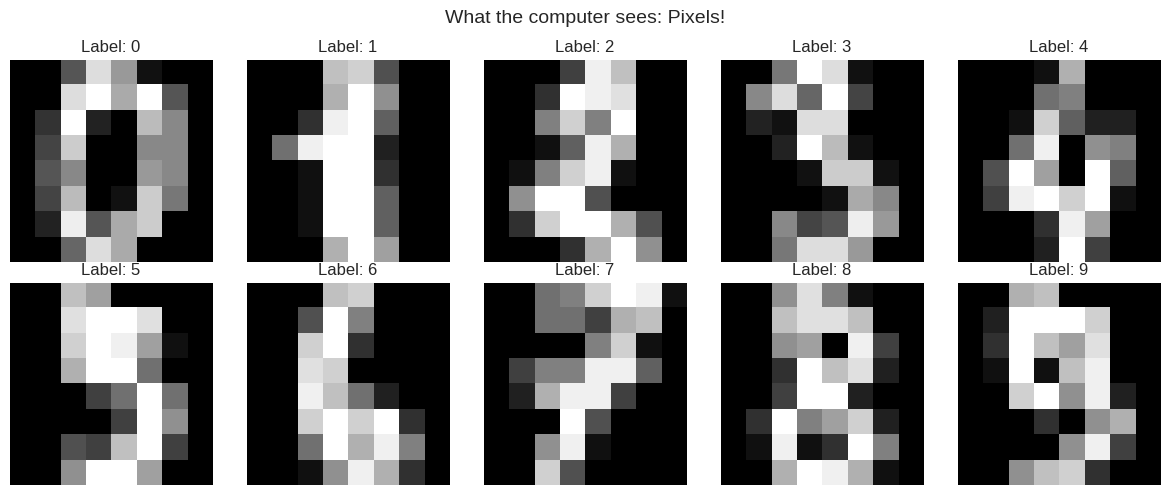

In [ ]:
# @title
# Let's see what the computer "sees"
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Label: {digits.target[i]}')
    ax.axis('off')

plt.suptitle('What the computer sees: Pixels!', fontsize=14)
plt.tight_layout()
plt.show()

### Part 2: Features and Labels
---

Features (X): What we use to make predictions

Labels (y): What we want to predict

In [ ]:
# Iris dataset
X = iris.data   # Features: sepal length/width, petal length/width
y = iris.target  # Labels: species (0, 1, or 2)

print("Features shape:", X.shape)  # (150 flowers, 4 features)
print("Labels shape:", y.shape)     # (150 labels)
print("\nFirst flower:")
print(f"  Features: {X[0]}")
print(f"  Label: {y[0]} ({iris.target_names[y[0]]})")

Features shape: (150, 4)
Labels shape: (150,)

First flower:
  Features: [5.1 3.5 1.4 0.2]
  Label: 0 (setosa)


### Part 3: Train/Test Split - The Most Important Concept!

---
Why? We need to test on data the model has NEVER seen.

In [ ]:
# The magic function
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,  # 20% for testing
    random_state=56  # For reproducibility
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\n💡 Rule of thumb: 80% train, 20% test")

Training set: 120 samples
Test set: 30 samples

💡 Rule of thumb: 80% train, 20% test


### Part 4: The sklearn API Pattern
---
Every sklearn model follows the same pattern:

```python
from sklearn.some_module import SomeModel

model = SomeModel()        # 1. Create
model.fit(X_train, y_train) # 2. Train
predictions = model.predict(X_test)  # 3. Predict
```


In [ ]:
# @title
# Let's try it!
from sklearn.neighbors import KNeighborsClassifier

# 1. Create the model
model = KNeighborsClassifier(n_neighbors=20)

# 2. Train on training data
model.fit(X_train, y_train)

# 3. Predict on test data
predictions = model.predict(X_test)

print(X_test.shape)

print("Predictions:", predictions[:10])
print("Actual:     ", y_test[:10])

print(X_test[0].shape)
predict=model.predict([X_test[0]])
print("Single prediction", predict)

(30, 4)
Predictions: [2 1 1 2 2 2 2 0 0 2]
Actual:      [2 1 1 2 2 2 2 0 0 2]
(4,)
Single prediction [2]


In [ ]:
# How good is it?
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print(f"\n🎯 Accuracy: {accuracy:.1%}")
print(f"\nThat means {int(accuracy * len(y_test))}/{len(y_test)} correct predictions!")


🎯 Accuracy: 96.7%

That means 29/30 correct predictions!


### Exercise: Perform Part 3 and 4 on digit data set. Check the performancs (Accuracy).

# Supervised Lerning

### Linear regression using Normal Equation

$
\hat{\theta} = (\mathbf{X}^T \mathbf{X})^{-1}\mathbf{X}^{T}\mathbf{y}
$

Caveat: Does not always work! $X^TX$ may, in rare cases, be not invertible.

In [ ]:
#The data is [1000,1500,2000,2500]  --- transpose
# Target is [42,58,83,97] --- transpose

X = np.array([[1, 1000], [1, 1500], [1, 2000], [1, 2500]])  # column of 1s for bias
y = np.array([42, 58, 83, 97])

theta = np.linalg.inv(X.T @ X) @ X.T @ y


print(f"bias = {theta[0]:.1f}, weight = {theta[1]:.4f}")

bias = 3.5, weight = 0.0380


Let us apply this on a bigger data set.

In [ ]:
# Create simple data: House size → Price
np.random.seed(50)
house_size = np.array([1000, 1500, 2000, 2500, 3000, 1200, 1800, 2200, 2800, 3500])
price = 0.04 * house_size + np.random.randn(10) * 5 + 10  # Price in lakhs

print(price)

[ 42.19823946  69.84511198  86.89535788 102.67709757 137.05973061
  55.61633928  78.09765393 103.35133868 115.58853702 143.36260549]


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


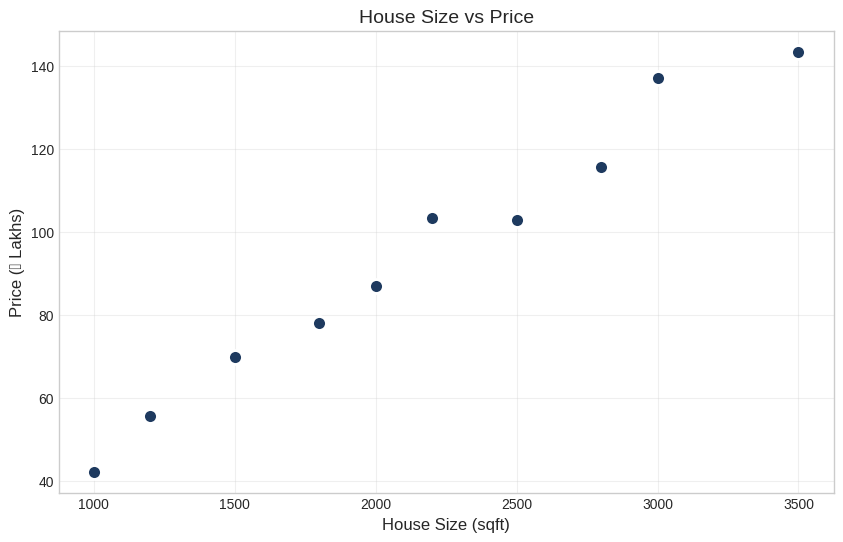

🤔 Can you see a pattern? Bigger house → Higher price!


In [ ]:
# @title
# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(house_size, price, s=100, color='#1e3a5f', edgecolors='white', linewidth=2)
plt.xlabel('House Size (sqft)', fontsize=12)
plt.ylabel('Price (₹ Lakhs)', fontsize=12)
plt.title('House Size vs Price', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print("🤔 Can you see a pattern? Bigger house → Higher price!")

The variable house_price is an array and not a matrix. We also need to **augment** it.

house_price ---> X ---> X_

In [ ]:
print("Shape of housesize", house_size.shape)
X = house_size.reshape(-1, 1)  # sklearn needs 2D array
print("Modified shape",X.shape)
y = price

print(X)
temp=np.ones((X.shape[0],1)) # np.ones((m,n)) creates a mxn matrix of 1's
print(temp)

X_ = np.hstack([temp,X]) # horizontally stack temp and X
print(X_)

Shape of housesize (10,)
Modified shape (10, 1)
[[1000]
 [1500]
 [2000]
 [2500]
 [3000]
 [1200]
 [1800]
 [2200]
 [2800]
 [3500]]
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]
[[1.0e+00 1.0e+03]
 [1.0e+00 1.5e+03]
 [1.0e+00 2.0e+03]
 [1.0e+00 2.5e+03]
 [1.0e+00 3.0e+03]
 [1.0e+00 1.2e+03]
 [1.0e+00 1.8e+03]
 [1.0e+00 2.2e+03]
 [1.0e+00 2.8e+03]
 [1.0e+00 3.5e+03]]


Let us apply linear regression using Normal Equation

In [ ]:

theta = np.linalg.inv(X_.T @ X_) @ X_.T @ y # Write your code here
print(f"bias = {theta[0]:.1f}, weight = {theta[1]:.4f}")


# Make a prediction
new_house = 1750
predicted_price = np.array([1, new_house]) @ theta
print(f"\n🏠 A {new_house} sqft house is predicted to cost ₹{predicted_price:.1f} lakhs")

bias = 6.1, weight = 0.0406

🏠 A 1750 sqft house is predicted to cost ₹77.2 lakhs


## Linear Regression for the same task.

In [ ]:
# Fit a line!
from sklearn.linear_model import LinearRegression

model = LinearRegression()
print(X.shape)
model.fit(X, y)

print(f"Slope (w): {model.coef_[0]:.4f}")
print(f"Intercept (b): {model.intercept_:.2f}")
print(f"\n📐 Equation: Price = {model.coef_[0]:.4f} × Size + {model.intercept_:.2f}")

(10, 1)
Slope (w): 0.0406
Intercept (b): 6.10

📐 Equation: Price = 0.0406 × Size + 6.10


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


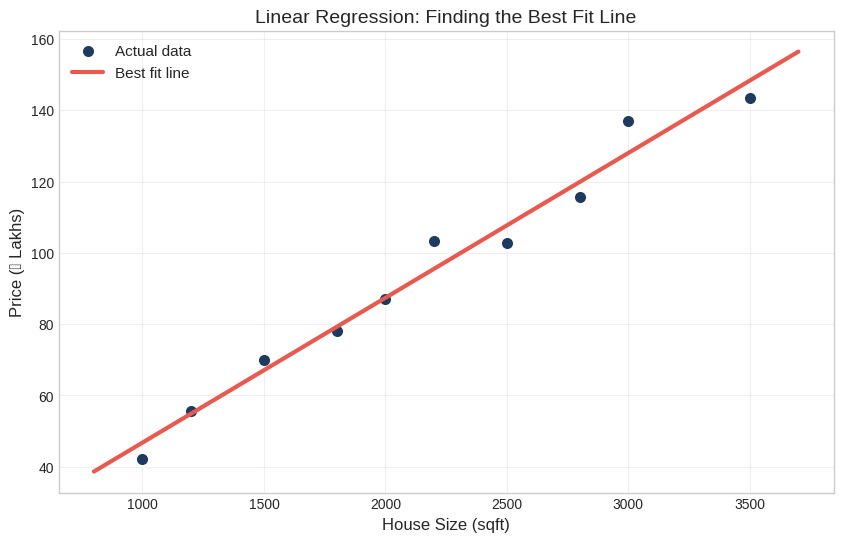


🏠 A 1750 sqft house is predicted to cost ₹77.2 lakhs


In [ ]:
# Visualize the fitted line
plt.figure(figsize=(10, 6))
plt.scatter(house_size, price, s=100, color='#1e3a5f', edgecolors='white', linewidth=2, label='Actual data')

# Plot the line
x_line = np.linspace(800, 3700, 100)
y_line = model.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, color='#e85a4f', linewidth=3, label='Best fit line')

plt.xlabel('House Size (sqft)', fontsize=12)
plt.ylabel('Price (₹ Lakhs)', fontsize=12)
plt.title('Linear Regression: Finding the Best Fit Line', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# Make a prediction
new_house = 1750
predicted_price = model.predict([[new_house]])[0]
print(f"\n🏠 A {new_house} sqft house is predicted to cost ₹{predicted_price:.1f} lakhs")

### Linear Regression with Gradient Descent with analytical gradients

$
\nabla_\theta\mathcal{L} = -\frac{2}{n}\mathbf{X}^T(\mathbf{y} - \hat{\mathbf{y}})
$

In [ ]:
def gradient_descent(X, y, lr=0.01, epochs=100):
    theta = np.zeros(X.shape[1])  # Start with zeros

    for epoch in range(epochs):
        y_pred = X @ theta             # Predictions
        error = y - y_pred             # Residuals
        gradient = (-2/len(y)) * (X.T @ error)
        theta = theta - lr * gradient  # Update!
        # print(theta)

    return theta

theta_gd = gradient_descent(X_, y)
print(f"bias = {theta_gd[0]:.1f}, weight = {theta_gd[1]:.4f}")

bias = nan, weight = nan


/tmp/ipython-input-536601071.py:5: RuntimeWarning: overflow encountered in matmul
  y_pred = X @ theta             # Predictions
/tmp/ipython-input-536601071.py:7: RuntimeWarning: overflow encountered in matmul
  gradient = (-2/len(y)) * (X.T @ error)
/tmp/ipython-input-536601071.py:8: RuntimeWarning: invalid value encountered in subtract
  theta = theta - lr * gradient  # Update!


The theta values are nan. Seems like there is numerical   instability. So, we must resacle the data.

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Standardization (most common)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) ## Assuming X as the train split.
print(X,"\n",X_scaled)

[[1000]
 [1500]
 [2000]
 [2500]
 [3000]
 [1200]
 [1800]
 [2200]
 [2800]
 [3500]] 
 [[-1.4990793 ]
 [-0.84730569]
 [-0.19553208]
 [ 0.45624153]
 [ 1.10801513]
 [-1.23836986]
 [-0.45624153]
 [ 0.06517736]
 [ 0.84730569]
 [ 1.75978874]]


In [ ]:
X_scaled_ = np.hstack([np.ones((X_scaled.shape[0], 1)), X_scaled])
theta_gd = gradient_descent(X_scaled_, y, lr=0.01, epochs=1000)
print(f"bias = {theta_gd[0]:.1f}, weight = {theta_gd[1]:.4f}")

bias = 93.5, weight = 31.1738


Now, how to the prediction?

In [ ]:
# Make a prediction
new_house = 1750
new_house_scaled = scaler.transform([[new_house]])
predicted_price = np.array([1, new_house_scaled[0,0]]) @ theta_gd
print(f"\n🏠 A {new_house} sqft house is predicted to cost ₹{predicted_price:.1f} lakhs")


🏠 A 1750 sqft house is predicted to cost ₹77.2 lakhs


### Transitioning to PyTorch

In [ ]:
import torch
import torch.nn as nn

X_scaled_tensor = torch.from_numpy(X_scaled).float()
print(X_scaled, X_scaled_tensor)
y_tensor = torch.from_numpy(y).float()
print(y_tensor)

model = nn.Linear(1, 1)
model.train()

criterion = nn.MSELoss()                              # Loss function
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)  # Optimizer

for epoch in range(100):
    y_pred = model(X_scaled_tensor)      # 1. Forward pass
    loss = criterion(y_pred, y_tensor) # 2. Compute loss
    optimizer.zero_grad()       # 3. Clear gradients
    loss.backward()             # 4. Compute gradients
    optimizer.step()            # 5. Update weights

print(f"bias = {model.bias.item():.1f}, weight = {model.weight.item():.4f}")

# Make a prediction
new_house = 1750
new_house_scaled = scaler.transform([[new_house]])
predicted_price = model(torch.tensor(new_house_scaled, dtype=torch.float32)).item()
print(f"\n🏠 A {new_house} sqft house is predicted to cost ₹{predicted_price:.1f} lakhs")

[[-1.4990793 ]
 [-0.84730569]
 [-0.19553208]
 [ 0.45624153]
 [ 1.10801513]
 [-1.23836986]
 [-0.45624153]
 [ 0.06517736]
 [ 0.84730569]
 [ 1.75978874]] tensor([[-1.4991],
        [-0.8473],
        [-0.1955],
        [ 0.4562],
        [ 1.1080],
        [-1.2384],
        [-0.4562],
        [ 0.0652],
        [ 0.8473],
        [ 1.7598]])
tensor([ 42.1982,  69.8451,  86.8954, 102.6771, 137.0597,  55.6163,  78.0977,
        103.3513, 115.5885, 143.3626])
bias = 81.0, weight = -0.0984

🏠 A 1750 sqft house is predicted to cost ₹81.0 lakhs


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([10])) that is different to the input size (torch.Size([10, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


## Exercises
---

```
# Exercise 1: Create dummy data with 5 features for Linear regression with 100 samples.
Perform 80-20 train test split. Compare the performance of all 4 version of linear regression as shown
in tutorial on the test set:

1. Sklearn
2. Closed form
3. Analytical Gradient
4. PyTorch

```


```
# Exercise 2: Create a linear regression on California housing data
`from sklearn.datasets import fetch_california_housing`
Predict house value from median income. Perform scaling and train test split.
Use sklearn's implementation for this exercise.

```

